<div style="
    width:100%;
    box-sizing:border-box;
    background:
        radial-gradient(circle at 82% 18%,rgba(37,99,235,0.10),transparent 25%),
        radial-gradient(circle at 95% 80%,rgba(14,165,233,0.09),transparent 28%),
        linear-gradient(135deg,#F3F6FA 0%,#FFFFFF 48%,#EEF5FC 100%);
    padding:30px 34px;
    border-radius:24px;
    font-family:'Segoe UI',Arial,sans-serif;
    border:1px solid #CBD5E1;
    box-shadow:0 10px 30px rgba(15,23,42,0.10);
">

<div style="display:flex;align-items:center;gap:12px;">

<div style="
    width:44px;height:44px;min-width:44px;border-radius:50%;
    background:#EFF6FF;border:2px solid #2563EB;
    box-shadow:0 0 16px rgba(37,99,235,0.20);
    display:flex;align-items:center;justify-content:center;font-size:20px;
">
🧪
</div>

<div>
<div style="color:#1D4ED8;font-size:13px;font-weight:900;letter-spacing:2px;">
HANDS-ON LAB
</div>
<div style="color:#172554;font-size:19px;font-weight:900;">
Sprint 1 Kickoff &amp; Baseline
</div>
</div>

</div>

<p style="color:#334155;font-size:14px;line-height:1.75;font-weight:600;margin:16px 0 0 0;">
🚀 In this lab we'll plan the sprint, finalize the dataset, explore it, train a
baseline model, and lock in the score every future model needs to beat.
</p>

</div>

<div style="
    width:100%;box-sizing:border-box;
    background:linear-gradient(135deg,#F3F6FA 0%,#FFFFFF 60%);
    padding:20px 24px;border-radius:18px;
    font-family:'Segoe UI',Arial,sans-serif;
    border:1px solid #CBD5E1;box-shadow:0 6px 18px rgba(15,23,42,0.08);
">
<div style="display:flex;align-items:center;gap:10px;margin-bottom:10px;">
<div style="width:28px;height:28px;border-radius:50%;background:#2563EB;color:#fff;
    font-size:13px;font-weight:900;display:flex;align-items:center;justify-content:center;">1</div>
<div style="color:#1D4ED8;font-size:12px;font-weight:900;letter-spacing:1.5px;">🗂️ SPRINT 1 PLANNING</div>
</div>
<p style="color:#172554;font-size:14px;line-height:1.7;font-weight:700;margin:0;">
Confirm the sprint goal and select the first backlog tasks: build a working
baseline model that predicts cardiovascular disease, and set the benchmark
every future model must beat. ✅
</p>
</div>

<div style="
    width:100%;box-sizing:border-box;
    background:linear-gradient(135deg,#F0F9FF 0%,#FFFFFF 60%);
    padding:20px 24px;border-radius:18px;
    font-family:'Segoe UI',Arial,sans-serif;
    border:1px solid #BAE6FD;box-shadow:0 6px 18px rgba(15,23,42,0.08);
">
<div style="display:flex;align-items:center;gap:10px;margin-bottom:10px;">
<div style="width:28px;height:28px;border-radius:50%;background:#0EA5E9;color:#fff;
    font-size:13px;font-weight:900;display:flex;align-items:center;justify-content:center;">2</div>
<div style="color:#0369A1;font-size:12px;font-weight:900;letter-spacing:1.5px;">📊 DATASET &amp; EDA</div>
</div>
<p style="color:#172554;font-size:14px;line-height:1.7;font-weight:700;margin:0;">
Finalize the project dataset and run a brief exploratory analysis: check shape,
missing values, target balance, and key correlations. 🔍
</p>
</div>

Shape: (70000, 13)

Missing values:
 id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Duplicates: 0

Target balance:
 cardio
0    0.5003
1    0.4997
Name: proportion, dtype: float64


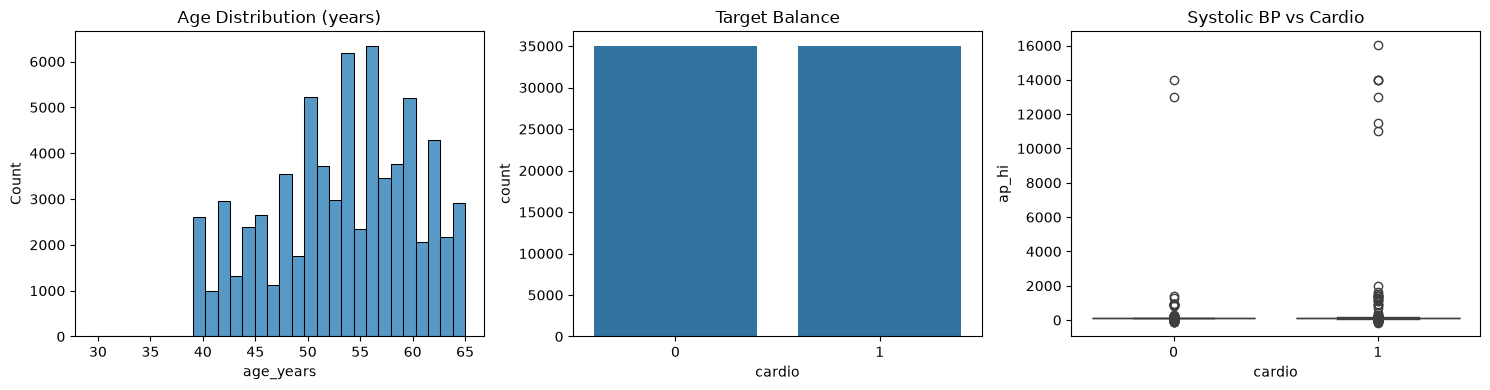


Correlation with target:
 cardio         1.000000
age            0.238159
age_years      0.238137
cholesterol    0.221147
weight         0.181660
gluc           0.089307
ap_lo          0.065719
ap_hi          0.054475
gender         0.008109
id             0.003799
alco          -0.007330
height        -0.010821
smoke         -0.015486
active        -0.035653
Name: cardio, dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('heart_disease_uci.csv', sep=';')

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

df['age_years'] = (df['age'] / 365).round(1)

print("\nTarget balance:\n", df['cardio'].value_counts(normalize=True))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['age_years'], bins=30, ax=axes[0]).set_title('Age Distribution (years)')
sns.countplot(x='cardio', data=df, ax=axes[1]).set_title('Target Balance')
sns.boxplot(x='cardio', y='ap_hi', data=df, ax=axes[2]).set_title('Systolic BP vs Cardio')
plt.tight_layout()
plt.show()

print("\nCorrelation with target:\n", df.corr(numeric_only=True)['cardio'].sort_values(ascending=False))

<div style="
    width:100%;box-sizing:border-box;
    background:linear-gradient(135deg,#FAF5FF 0%,#FFFFFF 60%);
    padding:20px 24px;border-radius:18px;
    font-family:'Segoe UI',Arial,sans-serif;
    border:1px solid #E9D5FF;box-shadow:0 6px 18px rgba(15,23,42,0.08);
">
<div style="display:flex;align-items:center;gap:10px;margin-bottom:10px;">
<div style="width:28px;height:28px;border-radius:50%;background:#7C3AED;color:#fff;
    font-size:13px;font-weight:900;display:flex;align-items:center;justify-content:center;">3</div>
<div style="color:#6D28D9;font-size:12px;font-weight:900;letter-spacing:1.5px;">🤖 BASELINE MODEL</div>
</div>
<p style="color:#172554;font-size:14px;line-height:1.7;font-weight:700;margin:0;">
Train a simple baseline model (Logistic Regression from Week 3) and record
its evaluation metric. 📈
</p>
</div>

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report

features = ['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
            'cholesterol', 'gluc', 'smoke', 'alco', 'active']
X = df[features]
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Baseline Accuracy: {accuracy:.3f}")
print(f"Baseline F1-score: {f1:.3f}")
print("\n", classification_report(y_test, y_pred))

Baseline Accuracy: 0.713
Baseline F1-score: 0.702

               precision    recall  f1-score   support

           0       0.70      0.75      0.72      7004
           1       0.73      0.67      0.70      6996

    accuracy                           0.71     14000
   macro avg       0.71      0.71      0.71     14000
weighted avg       0.71      0.71      0.71     14000



<div style="
    width:100%;box-sizing:border-box;
    background:linear-gradient(135deg,#F0FDF4 0%,#FFFFFF 60%);
    padding:20px 24px;border-radius:18px;
    font-family:'Segoe UI',Arial,sans-serif;
    border:1px solid #BBF7D0;box-shadow:0 6px 18px rgba(15,23,42,0.08);
">
<div style="display:flex;align-items:center;gap:10px;margin-bottom:10px;">
<div style="width:28px;height:28px;border-radius:50%;background:#16A34A;color:#fff;
    font-size:13px;font-weight:900;display:flex;align-items:center;justify-content:center;">4</div>
<div style="color:#15803D;font-size:12px;font-weight:900;letter-spacing:1.5px;">🔧 VERSION CONTROL</div>
</div>
<p style="color:#172554;font-size:14px;line-height:1.7;font-weight:700;margin:0;">
Commit the baseline notebook to a feature branch and open a Draft Pull Request
for review. 🚀
</p>
</div>

<div style="
    width:100%;box-sizing:border-box;
    background:linear-gradient(135deg,#FFF7ED 0%,#FFFFFF 60%);
    padding:20px 24px;border-radius:18px;
    font-family:'Segoe UI',Arial,sans-serif;
    border:1px solid #FED7AA;box-shadow:0 6px 18px rgba(15,23,42,0.08);
">
<div style="display:flex;align-items:center;gap:10px;margin-bottom:10px;">
<div style="width:28px;height:28px;border-radius:50%;background:#EA580C;color:#fff;
    font-size:13px;font-weight:900;display:flex;align-items:center;justify-content:center;">5</div>
<div style="color:#C2410C;font-size:12px;font-weight:900;letter-spacing:1.5px;">🏁 BASELINE SCORE TO BEAT</div>
</div>
<div style="background:#FFFFFF;border:1px solid #FED7AA;border-radius:12px;padding:12px 16px;text-align:center;">
<span style="color:#9A3412;font-size:16px;font-weight:900;">Accuracy: 71.3%  ·  F1-score: 0.702</span>
</div>
<p style="color:#7C2D12;font-size:12px;font-weight:700;margin:10px 0 0 0;">
⚠️ Every future model in this project must beat this score to count as an improvement.
</p>
</div>